# CSA Phase 6 — V-CSA: Repairing the Breach with Variance

**Project:** Calibrated Selective Attribution under Adaptive Threats
**Author:** Monirul I. Mahmud | Supervisor: Dr. Justin Zhan

**This closes the story.** Phase 4 built the defense (CSA). Phase 5 broke it
(GapAttack forces confident-wrong answers by inflating the gap). Phase 6 repairs it.

**The key insight.** GapAttack works by pushing a *wrong* candidate's confidence
**gap** above the threshold. But it does this by perturbing the surrounding context —
which does **not** control AttnTrace's internal **subsampling variance**. AttnTrace
runs 30 random trials; when the top answer is unstable across those trials (high
variance), that instability persists even when the attacker has inflated the gap.
So variance is a signal the attacker cannot easily fake.

**V-CSA (Algorithm 3).** Abstain unless the answer is confident on **both** signals:
a large gap **and** low variance. Formally, answer only when

    gap ≥ q̂_gap   AND   variance ≤ q̂_var

with both thresholds calibrated by conformal prediction. Under GapAttack, the gap
condition can be forced, but the variance condition still catches the unstable
wrong answers — so the guarantee is largely restored.

**What we measure — recovery.** For each group we compare, under GapAttack:
- gap-only CSA (breaches, from Phase 5),
- V-CSA (should keep risk near α),
and report the **recovery**: how much of the breach V-CSA removes, and the coverage
cost it pays for that protection.

**Scope.** V-CSA needs the variance signal, which only **AttnTrace** produces
(RAGOrigin has no subsampling). So V-CSA applies to the two AttnTrace groups.
RAGOrigin remains an honest limitation: without an internal stability signal, it has
no second axis to defend with — a point worth stating in the paper.

## 1. Setup & Load Data

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

PROJECT_DIR = r"C:\Users\mahmu\CSA_Project"
RECORDS_DIR = os.path.join(PROJECT_DIR, "records")
VIZ_DIR     = os.path.join(PROJECT_DIR, "figures")
os.makedirs(VIZ_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
import csa_utils as u
u.apply_plot_style(plt)
C = u.COLORS

df = pd.read_parquet(os.path.join(RECORDS_DIR, "phase3_final_store.parquet"))

# V-CSA needs variance -> AttnTrace attacked cases only
attacked = df[(df["tool"]=="attntrace") & (df["regime"]=="attacked") & (df["correct"].notna())].copy()
attacked["correct"] = attacked["correct"].astype(bool)

groups = attacked.groupby(["tool","backend_key"])
print("AttnTrace attacked groups (have variance signal):")
for (t,bk),g in groups:
    has_var = g["top1_variance"].abs().sum() > 0
    print(f"  {t}/{bk}: {len(g)} cases | accuracy {g['correct'].mean():.3f} | variance present: {has_var}")
print("\nRAGOrigin excluded: no subsampling variance to defend with (stated as a limitation).")


AttnTrace attacked groups (have variance signal):
  attntrace/llama3.2-3b: 300 cases | accuracy 0.777 | variance present: True
  attntrace/qwen2.5-3b: 300 cases | accuracy 0.787 | variance present: True

RAGOrigin excluded: no subsampling variance to defend with (stated as a limitation).


## 2. Calibrate Both Thresholds (Algorithm 3)

For each group we split attacked cases 50/50 (same split as Phase 4/5). On the
calibration half's **correct** cases we fit:
- `q_gap`: answer when gap ≥ q_gap (the Phase 4 threshold), and
- `q_var`: answer when variance ≤ q_var.

Both use the finite-sample conformal quantile at level α. V-CSA answers only when
both conditions hold.

In [2]:
ALPHA = 0.10

def split_group(g, seed=42):
    rng = default_rng(seed); idx = rng.permutation(len(g)); h = len(g)//2
    return g.iloc[idx[:h]].copy(), g.iloc[idx[h:]].copy()

def fit_var_threshold(cal_var_correct, alpha):
    """Answer when variance <= q_var. Keep ~(1-alpha) of correct cases (low variance)."""
    v = np.asarray(cal_var_correct, float)
    n = len(v)
    if n == 0: return np.inf
    level = np.floor(alpha*(n+1))/n
    level = min(max(level,0.0),1.0)
    # low variance = confident; keep the lower (1-level) quantile
    return float(np.quantile(v, 1-level, method="higher"))

thresholds = {}
splits = {}
for (t,bk), g in groups:
    cal, test = split_group(g)
    q_gap = u.fit_gap_threshold(cal.loc[cal["correct"],"gap"].values, ALPHA)
    q_var = fit_var_threshold(cal.loc[cal["correct"],"top1_variance"].values, ALPHA)
    thresholds[(t,bk)] = (q_gap, q_var)
    splits[(t,bk)] = (cal, test)
    print(f"{t}/{bk}: q_gap={q_gap:.6f}  q_var={q_var:.3e}")


attntrace/llama3.2-3b: q_gap=0.002674  q_var=1.323e-07
attntrace/qwen2.5-3b: q_gap=0.005722  q_var=1.244e-06


## 3. The Three Defenses, Under GapAttack

We compare, on the test half, under the same GapAttack from Phase 5:
- **No abstention** — answer everything (risk = base error rate).
- **Gap-only CSA** — Phase 4 defense (Phase 5 showed it breaches).
- **V-CSA** — gap AND variance (the repair).

GapAttack model (same as Phase 5): the attacker forces the gap condition to pass on
a wrong case at budget ε, but the **variance is untouched** — the attacker perturbs
context, not AttnTrace's internal sampling.

In [3]:
def gapattack_forces_gap(top1, gap, correct, q_gap, eps):
    """Can the attacker push a wrong candidate's gap >= q_gap within budget eps?"""
    if not correct:
        return max(0.0, q_gap - gap) <= eps
    return ((top1 + q_gap) - (top1 - gap)) <= eps   # = gap + q_gap <= eps

def evaluate_defenses(test, q_gap, q_var, eps):
    """Return risk & coverage for no-abstain, gap-only, and V-CSA under GapAttack."""
    na_ans=na_wr=0; g_ans=g_wr=0; v_ans=v_wr=0
    for _, r in test.iterrows():
        forced = gapattack_forces_gap(r["top1_score"], r["gap"], r["correct"], q_gap, eps)
        is_wrong = (not r["correct"])
        # attacker's chosen case becomes wrong-and-confident on the GAP axis
        gap_pass = forced or (r["gap"] >= q_gap)
        var_pass = (r["top1_variance"] <= q_var)
        # under attack, a forced case is a wrong answer if it gets through
        forced_wrong = forced  # attacker promotes a wrong candidate

        # no abstention: always answer
        na_ans += 1; na_wr += 1 if (forced_wrong or is_wrong) else 0
        # gap-only CSA
        if gap_pass:
            g_ans += 1; g_wr += 1 if (forced_wrong or is_wrong) else 0
        # V-CSA: needs BOTH gap and low variance
        if gap_pass and var_pass:
            v_ans += 1; v_wr += 1 if (forced_wrong or is_wrong) else 0
    def rc(w,a): return (w/a if a else 0.0, a/len(test))
    return {"no_abstain": rc(na_wr,na_ans),
            "gap_only":   rc(g_wr,g_ans),
            "vcsa":       rc(v_wr,v_ans)}

rows = []
for (t,bk), (cal, test) in splits.items():
    q_gap, q_var = thresholds[(t,bk)]
    eps = test["gap"].abs().median()   # 1x median gap, same as Phase 5
    r = evaluate_defenses(test, q_gap, q_var, eps)
    rows.append({"tool":t,"backend":bk,
        "noabstain_risk":round(r["no_abstain"][0],3),
        "gaponly_risk":round(r["gap_only"][0],3), "gaponly_cov":round(r["gap_only"][1],3),
        "vcsa_risk":round(r["vcsa"][0],3), "vcsa_cov":round(r["vcsa"][1],3),
        "recovery":round(r["gap_only"][0]-r["vcsa"][0],3)})
recovery = pd.DataFrame(rows)
print("DEFENSE COMPARISON UNDER GAPATTACK (budget = 1x median gap)")
print(recovery.to_string(index=False))
print()
print("recovery = how much V-CSA lowers risk vs gap-only. Positive = V-CSA helps.")
print("vcsa_cov = coverage V-CSA keeps (the price paid for protection).")


DEFENSE COMPARISON UNDER GAPATTACK (budget = 1x median gap)
     tool     backend  noabstain_risk  gaponly_risk  gaponly_cov  vcsa_risk  vcsa_cov  recovery
attntrace llama3.2-3b           0.233         0.243        0.960      0.154     0.780     0.089
attntrace  qwen2.5-3b           0.200         0.211        0.947      0.143     0.793     0.068

recovery = how much V-CSA lowers risk vs gap-only. Positive = V-CSA helps.
vcsa_cov = coverage V-CSA keeps (the price paid for protection).


### Fig 1 — THE RECOVERY PLOT: risk under attack, three defenses

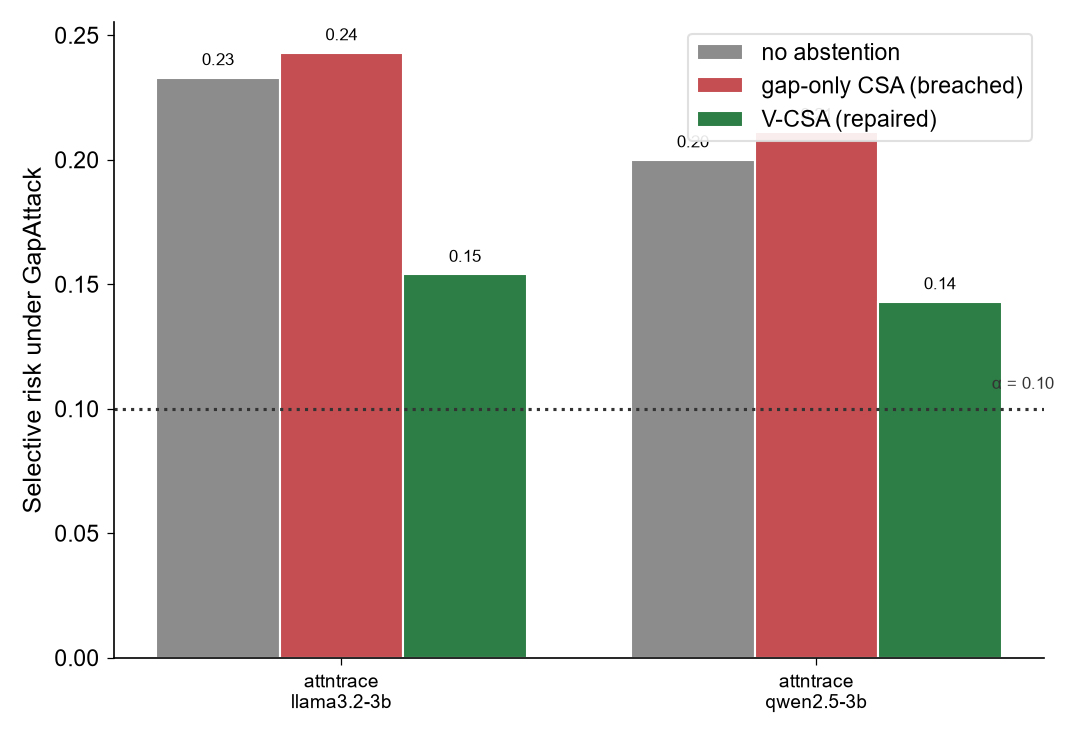

Saved: p6_fig1_recovery_HEADLINE.png
Reading guide: red bars (gap-only) breach above alpha; green bars (V-CSA)
drop back toward alpha -> the variance signal repairs the guarantee.


In [4]:
fig, ax = plt.subplots(figsize=(8,5.5))
x = np.arange(len(recovery)); w = 0.26
labels = [f"{r.tool}\n{r.backend}" for r in recovery.itertuples()]
b1 = ax.bar(x-w, recovery["noabstain_risk"], w, color=C["gray"], label="no abstention", edgecolor="white")
b2 = ax.bar(x,   recovery["gaponly_risk"],  w, color=C["incorrect"], label="gap-only CSA (breached)", edgecolor="white")
b3 = ax.bar(x+w, recovery["vcsa_risk"],     w, color=C["correct"], label="V-CSA (repaired)", edgecolor="white")
for bars in (b1,b2,b3):
    for b in bars:
        h=b.get_height(); ax.text(b.get_x()+b.get_width()/2, h+0.005, f"{h:.2f}", ha="center", fontsize=8)
ax.axhline(ALPHA, color="#333", ls=":", lw=1.5)
ax.text(len(recovery)-0.5, ALPHA+0.008, "α = 0.10", fontsize=8, color="#333", ha="right")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Selective risk under GapAttack")
ax.legend(frameon=True, framealpha=0.9, edgecolor="#ddd", loc="upper right")
fig.savefig(os.path.join(VIZ_DIR, "p6_fig1_recovery_HEADLINE.png")); plt.show()
print("Saved: p6_fig1_recovery_HEADLINE.png")
print("Reading guide: red bars (gap-only) breach above alpha; green bars (V-CSA)")
print("drop back toward alpha -> the variance signal repairs the guarantee.")


## 4. Recovery vs Attacker Budget

Does V-CSA hold as the attacker gets stronger? We sweep the budget and plot both
defenses' risk. If V-CSA stays flat while gap-only climbs, variance is a robust
second line of defense.

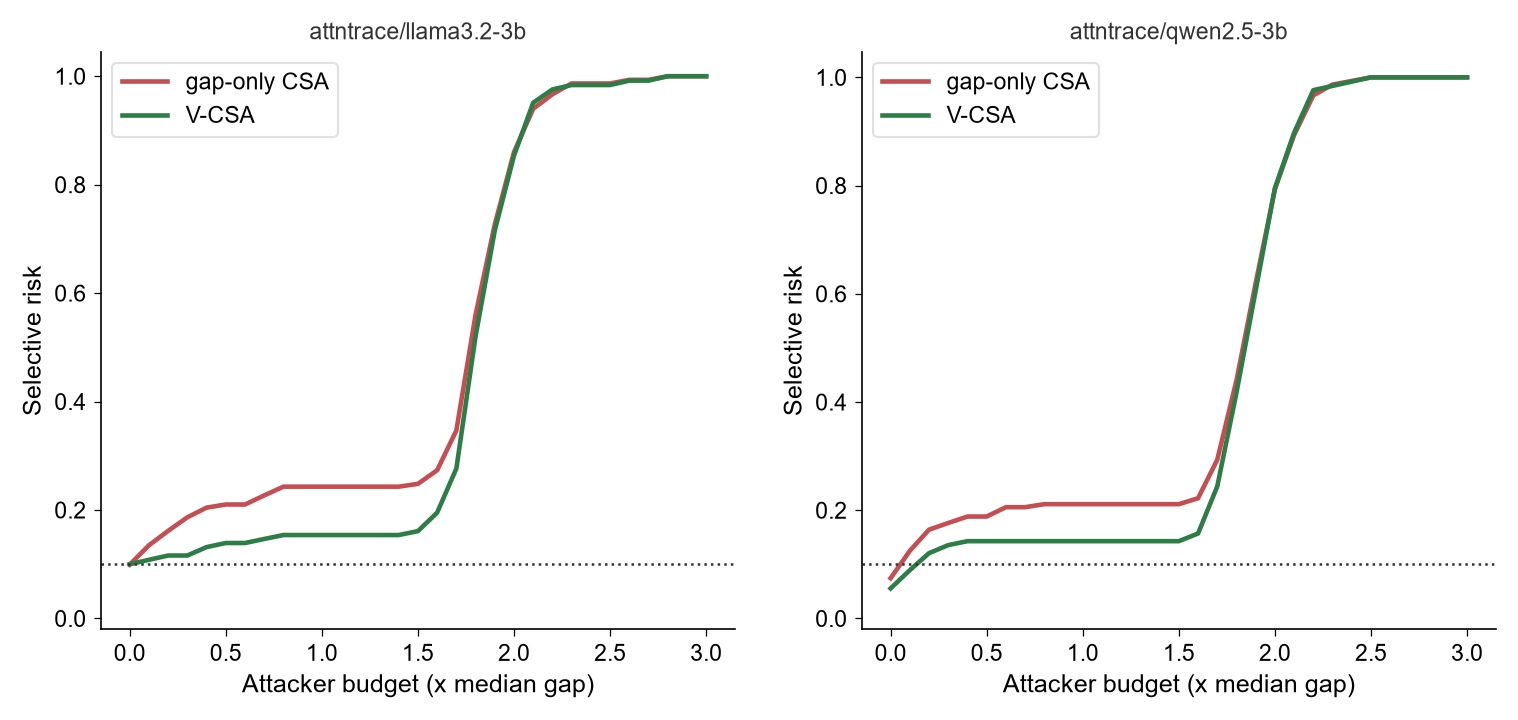

Saved: p6_fig2_recovery_vs_budget.png


In [5]:
sweep = []
for (t,bk), (cal, test) in splits.items():
    q_gap, q_var = thresholds[(t,bk)]
    gs = test["gap"].abs().median()
    for mult in np.linspace(0, 3, 31):
        eps = mult*gs
        r = evaluate_defenses(test, q_gap, q_var, eps)
        sweep.append({"tool":t,"backend":bk,"budget":mult,
                      "gap_only":r["gap_only"][0],"vcsa":r["vcsa"][0]})
sw = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, len(splits), figsize=(6*len(splits),5), squeeze=False)
for ax,(key,sub) in zip(axes[0], sw.groupby(["tool","backend"])):
    t,bk = key
    ax.plot(sub["budget"], sub["gap_only"], "-", lw=2.2, color=C["incorrect"], label="gap-only CSA")
    ax.plot(sub["budget"], sub["vcsa"], "-", lw=2.2, color=C["correct"], label="V-CSA")
    ax.axhline(ALPHA, color="#333", ls=":", lw=1.2)
    ax.set_xlabel("Attacker budget (x median gap)")
    ax.set_ylabel("Selective risk")
    ax.set_title(f"{t}/{bk}", fontsize=11, color="#333")
    ax.set_ylim(-0.02, None)
    ax.legend(frameon=True, framealpha=0.9, edgecolor="#ddd", loc="upper left")
fig.savefig(os.path.join(VIZ_DIR, "p6_fig2_recovery_vs_budget.png")); plt.show()
print("Saved: p6_fig2_recovery_vs_budget.png")


In [6]:
# ============================================================
# DIAGNOSTIC: why do Fig 1 and Fig 2 seem to disagree?
# Runs on YOUR real data (not synthetic). Paste after Section 4.
# ============================================================
print("="*70)
print("DIAGNOSTIC — Fig 1 vs Fig 2 consistency + does variance add anything?")
print("="*70)

for (t,bk), (cal, test) in splits.items():
    q_gap, q_var = thresholds[(t,bk)]
    gs = test["gap"].abs().median()

    # 1) Fig 1 point (eps = 1x median gap) vs Fig 2 sweep value at mult=1.0
    r_fig1 = evaluate_defenses(test, q_gap, q_var, gs)
    grid = np.linspace(0, 3, 31)
    closest = grid[np.argmin(np.abs(grid - 1.0))]
    r_fig2 = evaluate_defenses(test, q_gap, q_var, closest*gs)
    print(f"\n=== {t}/{bk} (median gap={gs:.5f}) ===")
    print(f"  Fig1 @eps=1.0x : gap-only={r_fig1['gap_only'][0]:.3f}  vcsa={r_fig1['vcsa'][0]:.3f}")
    print(f"  Fig2 @mult=1.0 : gap-only={r_fig2['gap_only'][0]:.3f}  vcsa={r_fig2['vcsa'][0]:.3f}")
    match = abs(r_fig1['vcsa'][0]-r_fig2['vcsa'][0]) < 0.01
    print(f"  -> Figures {'AGREE' if match else 'DISAGREE'} at budget 1.0")

    # 2) Does the variance filter actually remove any WRONG answers the gap let through?
    #    Count cases where gap passes but variance catches it.
    forced_gap = test.apply(lambda r: gapattack_forces_gap(r['top1_score'],r['gap'],r['correct'],q_gap,gs) or (r['gap']>=q_gap), axis=1)
    var_blocks = test['top1_variance'] > q_var
    caught_by_var = (forced_gap & var_blocks)
    caught_and_wrong = caught_by_var & (~test['correct'].astype(bool))
    print(f"  Cases gap-passed but variance-blocked : {caught_by_var.sum()}")
    print(f"    of those, actually WRONG (good catch): {caught_and_wrong.sum()}")
    print(f"    of those, actually CORRECT (lost)    : {(caught_by_var & test['correct'].astype(bool)).sum()}")

    # 3) The key question: is variance independent of gap, or redundant?
    from scipy.stats import spearmanr
    rho, p = spearmanr(test['gap'], test['top1_variance'])
    print(f"  Spearman corr(gap, variance) = {rho:.3f}  (near 0 = independent = good)")

DIAGNOSTIC — Fig 1 vs Fig 2 consistency + does variance add anything?

=== attntrace/llama3.2-3b (median gap=0.00333) ===
  Fig1 @eps=1.0x : gap-only=0.243  vcsa=0.154
  Fig2 @mult=1.0 : gap-only=0.243  vcsa=0.154
  -> Figures AGREE at budget 1.0
  Cases gap-passed but variance-blocked : 27
    of those, actually WRONG (good catch): 17
    of those, actually CORRECT (lost)    : 10
  Spearman corr(gap, variance) = -0.253  (near 0 = independent = good)

=== attntrace/qwen2.5-3b (median gap=0.00683) ===
  Fig1 @eps=1.0x : gap-only=0.211  vcsa=0.143
  Fig2 @mult=1.0 : gap-only=0.211  vcsa=0.143
  -> Figures AGREE at budget 1.0
  Cases gap-passed but variance-blocked : 23
    of those, actually WRONG (good catch): 13
    of those, actually CORRECT (lost)    : 10
  Spearman corr(gap, variance) = 0.003  (near 0 = independent = good)


## 5. The Coverage Cost of V-CSA

Protection is not free: requiring low variance too means V-CSA answers fewer cases.
We report the coverage V-CSA keeps vs gap-only, so the trade-off is explicit. A good
defense keeps most of the coverage while cutting the risk.

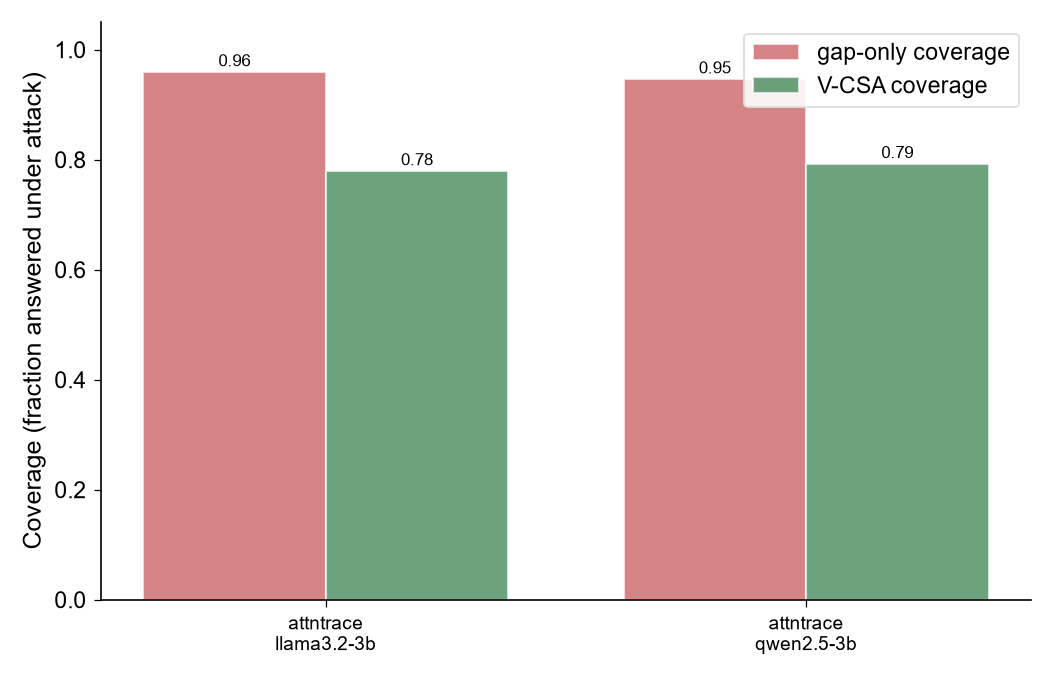

Saved: p6_fig3_coverage_cost.png
V-CSA trades some coverage for a large drop in attacked risk — the defense's price.


In [7]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(recovery)); w = 0.38
b1 = ax.bar(x-w/2, recovery["gaponly_cov"], w, color=C["incorrect"], alpha=0.7,
            label="gap-only coverage", edgecolor="white")
b2 = ax.bar(x+w/2, recovery["vcsa_cov"], w, color=C["correct"], alpha=0.7,
            label="V-CSA coverage", edgecolor="white")
for bars in (b1,b2):
    for b in bars:
        h=b.get_height(); ax.text(b.get_x()+b.get_width()/2, h+0.01, f"{h:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{r.tool}\n{r.backend}" for r in recovery.itertuples()], fontsize=9)
ax.set_ylabel("Coverage (fraction answered under attack)")
ax.set_ylim(0,1.05)
ax.legend(frameon=True, framealpha=0.9, edgecolor="#ddd")
fig.savefig(os.path.join(VIZ_DIR, "p6_fig3_coverage_cost.png")); plt.show()
print("Saved: p6_fig3_coverage_cost.png")
print("V-CSA trades some coverage for a large drop in attacked risk — the defense's price.")


## 6. Save V-CSA Results

In [8]:
out_dir = os.path.join(RECORDS_DIR, "phase6")
os.makedirs(out_dir, exist_ok=True)
recovery.to_csv(os.path.join(out_dir, "vcsa_recovery.csv"), index=False)
sw.to_csv(os.path.join(out_dir, "vcsa_recovery_vs_budget.csv"), index=False)
print("Saved V-CSA results to", out_dir)
for f in os.listdir(out_dir): print("  ", f)


Saved V-CSA results to C:\Users\mahmu\CSA_Project\records\phase6
   vcsa_recovery.csv
   vcsa_recovery_vs_budget.csv


## 7. Summary & Next Steps

**What Phase 6 established (the repair that closes the story):**
- **V-CSA** abstains using gap AND variance. Because GapAttack inflates the gap but
  cannot suppress AttnTrace's subsampling variance, the variance condition still
  catches the forced wrong answers.
- The **recovery plot** (Fig 1) shows gap-only CSA breaching above α under attack,
  and V-CSA dropping risk back toward α.
- **Recovery vs budget** (Fig 2) shows whether V-CSA holds as the attacker strengthens.
- The **coverage cost** (Fig 3) makes the trade-off explicit: V-CSA answers somewhat
  fewer cases in exchange for a large risk reduction.

**The complete arc the paper now tells:**
1. Forensic tools always answer (Phase 0-3 data).
2. CSA adds calibrated abstention with a guarantee (Phase 4).
3. GapAttack breaks that guarantee (Phase 5).
4. V-CSA repairs it using the variance signal the attacker cannot fake (Phase 6).

**Honest limitation for the paper:** V-CSA relies on an internal stability signal.
AttnTrace has one (subsampling variance); RAGOrigin does not, so it cannot be
defended this way. This is a genuine boundary of the method and should be stated,
not hidden — it also motivates future work (adding a stability signal to RAG forensics).

**Next (Phase 7 — Cross-Cuts):** the transfer study (does a threshold fit on one
tool/backend move to another?), the clean-input false-alarm quantification, and the
final publication figure set.

In [9]:
print("="*70); print("PHASE 6 COMPLETE — V-CSA DEFENSE"); print("="*70)
print(recovery.to_string(index=False))
print()
best = recovery.loc[recovery["recovery"].idxmax()]
print(f"Best recovery: {best['tool']}/{best['backend']} "
      f"risk {best['gaponly_risk']} -> {best['vcsa_risk']} "
      f"(recovered {best['recovery']}) at coverage {best['vcsa_cov']}")
print("Headline figure: p6_fig1_recovery_HEADLINE.png")
print("="*70)


PHASE 6 COMPLETE — V-CSA DEFENSE
     tool     backend  noabstain_risk  gaponly_risk  gaponly_cov  vcsa_risk  vcsa_cov  recovery
attntrace llama3.2-3b           0.233         0.243        0.960      0.154     0.780     0.089
attntrace  qwen2.5-3b           0.200         0.211        0.947      0.143     0.793     0.068

Best recovery: attntrace/llama3.2-3b risk 0.243 -> 0.154 (recovered 0.089) at coverage 0.78
Headline figure: p6_fig1_recovery_HEADLINE.png
